# Optimal protocols for vaccination



In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
import pandas as pd
import matplotlib.lines as mlines


os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")

from fokker_planck import run_fp, plot_fp_density_time_dim

import sys
sys.path.append('../stochastic')

from stochastic_simul import simulate_gc_with_ancestry 


# Optimal concentration schedule C*

In [2]:
df=pd.read_csv("c_star_over_time.csv")
times=df['time'].values
c_star=df['c_star'].values


# Vaccination parameters using MSE loss

We can get a nearly optimal concentration schedule by matching the target C* with MSE gradient descent. 

In [3]:
class ImmunizationOptimizer(nn.Module):
    def __init__(self, N, tau, initial_C_values, initial_interval_values):
        super().__init__()
        self.N = N
        self.tau = float(tau)
        
        # Helper for inverse softplus: x = ln(exp(y) - 1)
        def inverse_softplus(y):
            return np.log(np.exp(y) + 1e-6 - 1)

        # 1. Parameter for Concentrations (log_C)
        # We initialize in log space. max() ensures we don't take log of 0 or negative numbers.
        init_log_C = [np.log(max(val, 1e-8)) for val in initial_C_values]
        self.log_C = nn.Parameter(torch.tensor(init_log_C, dtype=torch.float32))
        
        # 2. Parameter for Time Intervals (dt)
        if N > 1:
            init_dt_raw = [inverse_softplus(val) for val in initial_interval_values]
            self.raw_dt = nn.Parameter(torch.tensor(init_dt_raw, dtype=torch.float32))
        else:
            self.raw_dt = None

    def get_physical_parameters(self):
        # Ensure Positive Concentrations by taking the exponential of the log parameter
        C_i = torch.exp(self.log_C)
        
        # Construct Times from Intervals
        t_1 = torch.tensor([0.0], device=self.log_C.device)
        if self.N > 1:
            intervals = torch.nn.functional.softplus(self.raw_dt)
            later_times = torch.cumsum(intervals, dim=0)
            t_i = torch.cat([t_1, later_times])
        else:
            t_i = t_1
            
        return C_i, t_i

    def forward(self, t_eval, sigmoid_steepness=50.0):
        C_i, t_i = self.get_physical_parameters()
        
        t_eval = t_eval.view(-1, 1)
        t_i = t_i.view(1, -1)
        C_i = C_i.view(1, -1)
        
        dt = t_eval - t_i
        
        # Differentiable Step Function
        step_approx = torch.sigmoid(sigmoid_steepness * dt)
        
        safe_dt = torch.relu(dt)
        decay = torch.exp(-safe_dt / self.tau)
        
        concentration_matrix = step_approx * C_i * decay
        C_total = torch.sum(concentration_matrix, dim=1)
        
        return C_total


def find_optimal_parameters(N, tau, t_eval_array, C_star_array, epochs=4000, lr=0.1):
    # Base interval assumption for initialization
    interval_guess = 20.0
    init_intervals = [interval_guess] * (N - 1)
    init_C_values = []
    
    for i in range(N):
        expected_time = i * interval_guess
        idx = (np.abs(t_eval_array - expected_time)).argmin()
        
        # Get the target value at this time step
        target_val = max(float(C_star_array[idx]), 1e-4)
        
        # Analytically scale the initialization to prevent underdose during the interval
        # C_initial = C_target * exp(dt / tau)
        safe_val = target_val * np.exp(interval_guess / tau)
        
        init_C_values.append(safe_val)

    t_tensor = torch.tensor(t_eval_array, dtype=torch.float32)
    C_star_tensor = torch.tensor(C_star_array, dtype=torch.float32)
    
    model = ImmunizationOptimizer(N, tau, init_C_values, init_intervals)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # --- Barrier Hyperparameters ---
    # barrier_weight (lambda): Scales the overall impact of the penalty.
    barrier_weight = 0 # no penalty

    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Annealing
        current_steepness = 10.0 + (90.0 * epoch / epochs)
        
        C_simulated = model(t_tensor, sigmoid_steepness=current_steepness)
        
        # Compute Log Difference
        log_C_simulated = torch.log(C_simulated + 1e-8)
        log_C_star = torch.log(C_star_tensor + 1e-8)
        
        # 1. Base MSE (handles general curve fitting and over-dosing)
        mse_loss = torch.mean((log_C_simulated - log_C_star) ** 2)
        
        # 2. Exponential Barrier (handles under-dosing)
        underdose_amount = torch.relu(log_C_star - log_C_simulated)
        
        underdose_amount_clamped = torch.clamp(underdose_amount, max=5.0)
        
        mse_underdose=torch.mean(underdose_amount_clamped ** 2)* barrier_weight
        # Combine losses
        loss = mse_loss + mse_underdose

        loss.backward()
        
        # Gradient clipping is crucial here so the exponential penalty doesn't destabilize Adam
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        
        optimizer.step()

    final_C, final_t = model.get_physical_parameters()
    
    return {
        "C_optimized": final_C.detach().numpy(),
        "t_optimized": final_t.detach().numpy(),
        "final_loss": loss.item(),
        'C_simulated': C_simulated.detach().numpy()
    }

In [4]:
tau_val = 20.0

N_injections = 1

result1 = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result1['C_optimized'])
print("Optimized Times (t):", result1['t_optimized'])

N_injections = 2

result2 = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result2['C_optimized'])
print("Optimized Times (t):", result2['t_optimized'])

N_injections = 3

result3 = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result3['C_optimized'])
print("Optimized Times (t):", result3['t_optimized'])




Final Result:
Optimized Injections (C): [119.14573]
Optimized Times (t): [0.]

Final Result:
Optimized Injections (C): [34.081005 10.942306]
Optimized Times (t): [ 0.       80.972244]

Final Result:
Optimized Injections (C): [26.153332  5.668279  5.725831]
Optimized Times (t): [  0.        65.025894 102.456345]


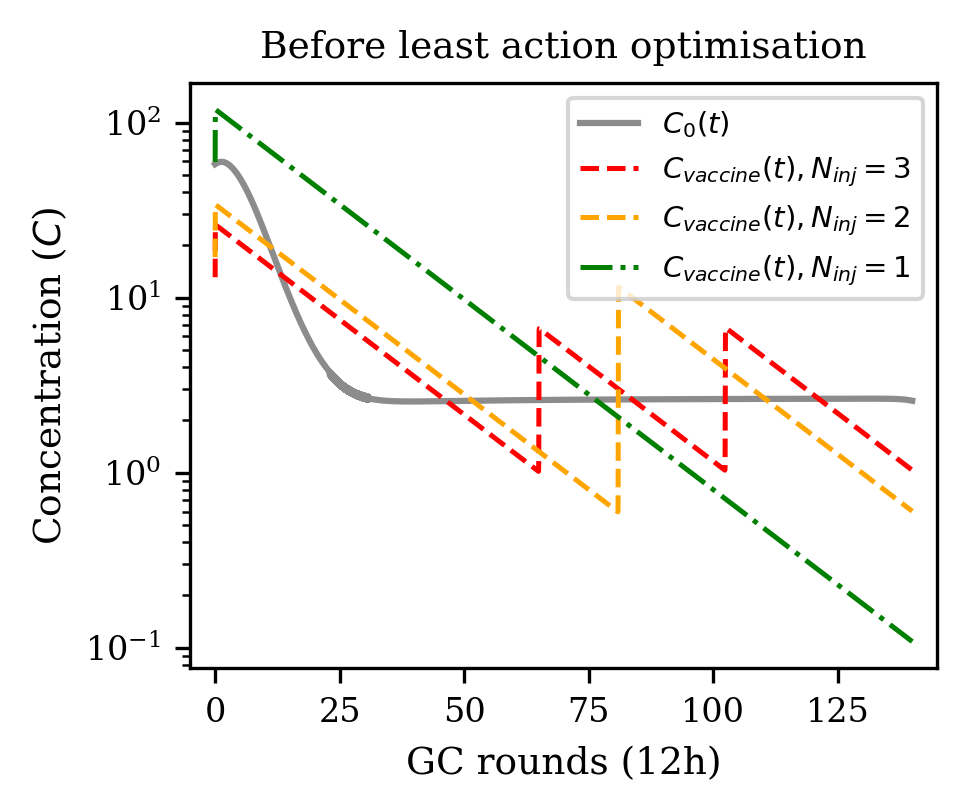

In [5]:
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
    "font.family": "serif",        # Often preferred in papers
})




t_inj1 = result1['t_optimized']  # Injection times
C_inj1 = result1['C_optimized']  # Injection doses 
C_sim1 = result1['C_simulated'].flatten() # Simulated Response

t_inj2 = result2['t_optimized']  # Injection times
C_inj2 = result2['C_optimized']  # Injection doses 
C_sim2 = result2['C_simulated'].flatten() # Simulated Response

t_inj3 = result3['t_optimized']  # Injection times
C_inj3 = result3['C_optimized']  # Injection doses 
C_sim3 = result3['C_simulated'].flatten() # Simulated Response

t_sim = times
C_ref = c_star


fig, ax = plt.subplots()



# Target C* (Dashed, Lighter Blue)
ax.plot(t_sim, C_ref, 
        label=r"$C_0(t)$", 
        color='grey',       # Soft Blue
        linestyle='-', 
        linewidth=1.5,
        alpha=0.9)

# Simulated C (Solid, Darker/Rich Blue)
ax.plot(t_sim, C_sim3, 
        label=r"$C_{vaccine}(t), N_{inj}=3$",
        color='red',       # Navy Blue
        linestyle='--', 
        linewidth=1.2)

ax.plot(t_sim, C_sim2, 
        label=r"$C_{vaccine}(t), N_{inj}=2$",
        color='orange',       # Navy Blue
        linestyle='--', 
        linewidth=1.2)


ax.plot(t_sim, C_sim1, 
        label=r"$C_{vaccine}(t), N_{inj}=1$",
        color='green',       # Navy Blue
        linestyle='-.', 
        linewidth=1.2)



ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Concentration ($C$)")
ax.set_xlim(t_sim[0], t_sim[-1])
plt.yscale("log")  # Log scale for better visibility of differences

ax.grid(False)

ax.legend(frameon=True, loc='best', fontsize=7)


fig.tight_layout()
plt.xlim(-5, 145)
plt.title('Before least action optimisation')

plt.show()


# Vaccination parameters optimized using least action

Vaccination parameters can be further optimized by minimizing the least action $S$. 

```bash
python script_vaccine_optim.py --target_hf 30 --tau 20.0 



In [6]:
results_dir = "results_1_1_alpha10_clipbound1.33"

target_hf = 30
tau = 20.0


In [7]:
basal_C = 1e-12

t_arr = np.asarray(times, dtype=float)

C_sim1_opti = np.full_like(t_arr, basal_C, dtype=float)
C_sim2_opti = np.full_like(t_arr, basal_C, dtype=float)
C_sim3_opti = np.full_like(t_arr, basal_C, dtype=float)

opti_arrays = {1: C_sim1_opti, 2: C_sim2_opti, 3: C_sim3_opti}


for ninj in [1, 2, 3]:
    file_int = os.path.join(results_dir, f"optimized_params_hf_{target_hf}_ninj_{ninj}_tau_{tau}.csv")
    file_float = os.path.join(results_dir, f"optimized_params_hf_{float(target_hf)}_ninj_{ninj}_tau_{tau}.csv")
    filepath = file_int if os.path.exists(file_int) else file_float
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        c_params = df['dose_C'].values
        t_params = df['time_t'].values
        
        # Calculate concentration over time using exponential decay
        for ci, ti in zip(c_params, t_params):
            mask = t_arr >= ti
            opti_arrays[ninj][mask] += ci * np.exp(-(t_arr[mask] - ti) / tau)
            
    else:
        print(f"Warning: Could not find parameter file for {ninj} injection(s). Looked for: {filepath}")


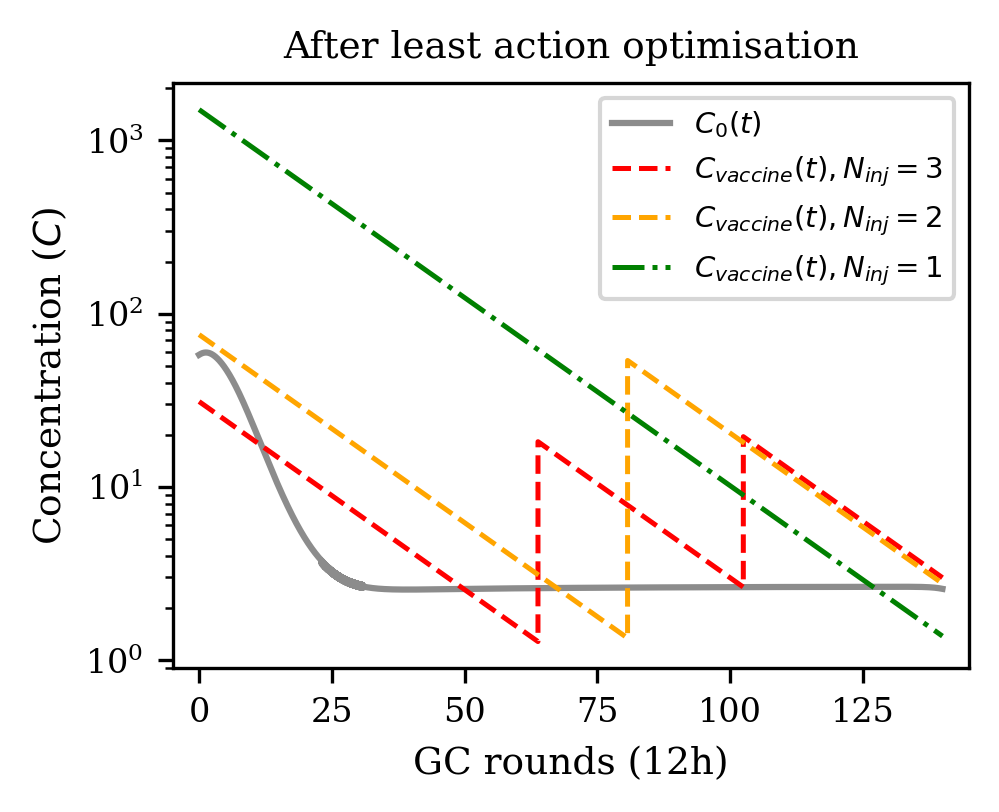

In [8]:


plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
    "font.family": "serif",        # Preferred in papers
})


t_arr = times
C_0 = c_star

fig, ax = plt.subplots()


ax.plot(
    t_arr, 
    C_0, 
    label=r"$C_0(t)$", 
    color='grey', 
    linestyle='-', 
    linewidth=1.5,
    alpha=0.9
)

plot_configs = [
    (3, C_sim3_opti, "red", "--"),
    (2, C_sim2_opti, "orange", "--"),
    (1, C_sim1_opti, "green", "-.")
]

for ninj, y_data, color, linestyle in plot_configs:
    ax.plot(
        t_arr, 
        y_data, 
        label=rf"$C_{{vaccine}}(t), N_{{inj}}={ninj}$",
        color=color, 
        linestyle=linestyle, 
        linewidth=1.2
    )


ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Concentration ($C$)")
ax.set_xlim(-5, 145)
plt.yscale("log")  
ax.grid(False)

ax.legend(frameon=True, loc='best', fontsize=7)

fig.tight_layout()
plt.title('After least action optimisation')

plt.show()


In [9]:
def make_get_C_from_cstar(times, c_star):
    times = np.asarray(times, dtype=float)
    c_star = np.asarray(c_star, dtype=float)
    t0, tf = float(times[0]), float(times[-1])

    def get_C_star(t, v):
        # same concentration for all antigens v
        t = float(t)
        if t <= t0:
            return float(c_star[0])
        if t >= tf:
            return float(c_star[-1])
        return float(np.interp(t, times, c_star))
    return get_C_star


In [10]:
get_C_star_vacc1 = make_get_C_from_cstar(times, C_sim1_opti)
get_C_star_vacc2 = make_get_C_from_cstar(times, C_sim2_opti)
get_C_star_vacc3 = make_get_C_from_cstar(times, C_sim3_opti)
get_C_star=make_get_C_from_cstar(times, c_star)

df_vacc = pd.DataFrame({"time": times, "C_vaccine_Ninj3": C_sim3_opti, "C_vaccine_Ninj2": C_sim2_opti, "C_vaccine_Ninj1": C_sim1_opti})
df_vacc.to_csv("optimized_vaccine_concentration_opti.csv", index=False)


In [11]:
T=140
fp_ctx_opt_vacc1 = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc1,
    T=T,
    verbose=False
)

fp_ctx_opt_vacc2 = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc2,
    T=T,
    verbose=False
)

fp_ctx_opt_vacc3 = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc3,
    T=T,
    verbose=False
)

In [12]:
def _marginal_last(fp_ctx):
    """
    Return (h1_axis, pdf_h1) for the last snapshot in fp_ctx 
    """
    axes = fp_ctx["axes"]               # tuple/list of 1D arrays
    N_h  = len(axes)
    h1_axis = axes[0]
    d_h = h1_axis[1] - h1_axis[0]
    
    # Calculate the N-dimensional volume element

    rho_stack = fp_ctx["rho_t"]
    
    # Boolean mask for the region strictly above h_c on the h1 axis
    
    best_index = -1
    
 

    rho_alive = rho_stack[best_index]

    if N_h == 1:
        rho1 = rho_alive.copy()
    else:
        # integrate out h2..hN with Riemann sum
        rho1 = rho_alive.sum(axis=tuple(range(1, N_h))) * (d_h ** (N_h - 1))

    # Keep as raw marginal density to match the histogram's rho_eps scale
    pdf = rho1 
        
    return h1_axis, pdf

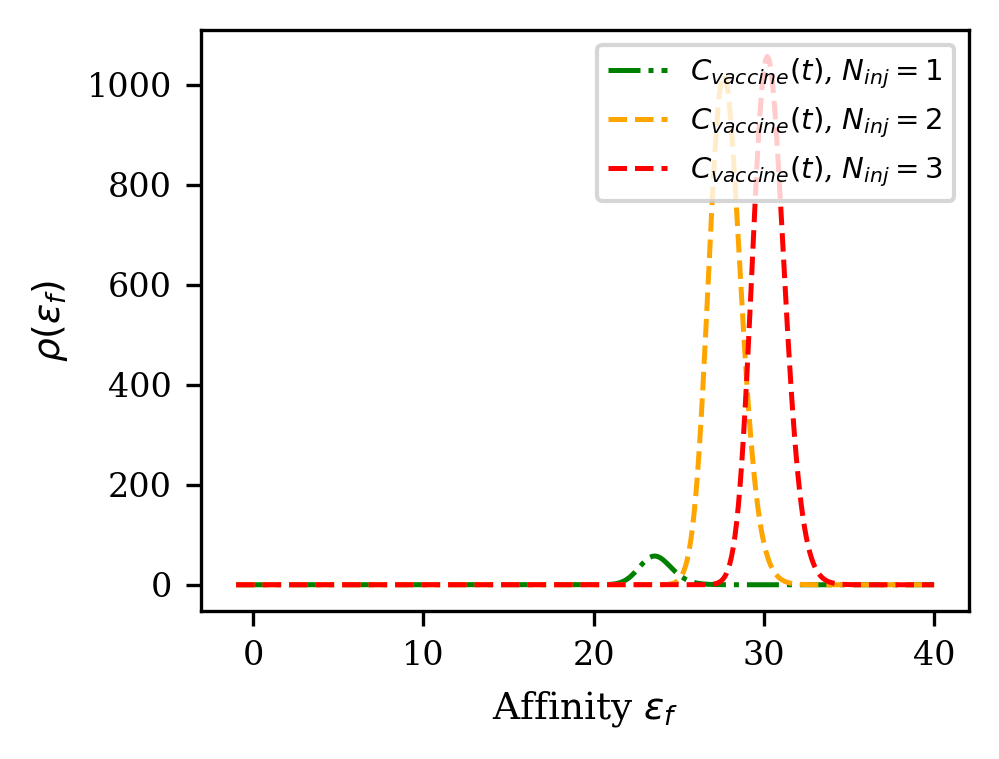

In [13]:
h1_opt_vacc1, pdf_opt_vacc1 = _marginal_last(fp_ctx_opt_vacc1)
h1_opt_vacc2, pdf_opt_vacc2 = _marginal_last(fp_ctx_opt_vacc2)
h1_opt_vacc3, pdf_opt_vacc3 = _marginal_last(fp_ctx_opt_vacc3)


plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  
    "figure.dpi": 300,
})

fig, ax = plt.subplots()


ax.plot(h1_opt_vacc1, pdf_opt_vacc1, label=r"$C_{vaccine}(t)$, $N_{inj}=1$",                linestyle='-.',  linewidth=1.2, color='green')
ax.plot(h1_opt_vacc2, pdf_opt_vacc2, label=r"$C_{vaccine}(t)$, $N_{inj}=2$",                linestyle='--',  linewidth=1.2, color='orange')
ax.plot(h1_opt_vacc3, pdf_opt_vacc3, label=r"$C_{vaccine}(t)$, $N_{inj}=3$",                linestyle='--',  linewidth=1.2, color='red')


ax.set_xlabel(r"Affinity $\epsilon_f$")
ax.set_ylabel(r"$\rho(\epsilon_f)$")

ax.grid(False)

ax.legend(frameon=True, loc='upper right', fontsize=7)


fig.tight_layout()
plt.show()


# Final affinity as a function of $\tau$ and $N_{inj}$

In [14]:


N_inj_array = [1,2, 3]
Tau_array = [10,20,30,40]

results = {n: [] for n in N_inj_array}

for N_injections in N_inj_array:
    for tau_val in Tau_array:
        
        file_int = os.path.join(results_dir, f"optimized_params_hf_{target_hf}_ninj_{N_injections}_tau_{tau_val}.csv")
        file_float = os.path.join(results_dir, f"optimized_params_hf_{float(target_hf)}_ninj_{N_injections}_tau_{float(tau_val)}.csv")
    
        filepath = file_int if os.path.exists(file_int) else file_float
        try:
            param_df=pd.read_csv(filepath)
        except FileNotFoundError:
            print(f"Warning: Could not find parameter file for N={N_injections}, tau={tau_val}. Looked for: {filepath}")
            continue

        concentrations = param_df['dose_C'].values
        injection_times = param_df['time_t'].values

        print(f"Loaded parameters for N={N_injections}, tau={tau_val}:")
        print(f"Concentrations: {concentrations}")
        print(f"Injection Times: {injection_times}")

        C_sim = np.full_like(times, 1e-12, dtype=float)
        for ci, ti in zip(concentrations, injection_times):
            mask = times >= ti
            C_sim[mask] += ci * np.exp(-(times[mask] - ti) / tau_val)

        get_C_star_vacc = make_get_C_from_cstar(times, C_sim)

        fp_ctx_opt_vacc = run_fp(
            get_S=lambda t: np.array([[1.0]]),  
            get_C=get_C_star_vacc,
            T=T,
            verbose=False, 
            
        )
        
        h1_opt, pdf_opt = _marginal_last(fp_ctx_opt_vacc)
     

        mean = np.average(h1_opt, weights=pdf_opt)
        if np.isnan(mean):
            print("nan")
            mean = 0.0
        print(f"Mean h1 for N={N_injections}, tau={tau_val}: {mean:.2f}")

        results[N_injections].append((tau_val, mean, concentrations, injection_times))


Loaded parameters for N=1, tau=10:
Concentrations: [630699.04901033]
Injection Times: [0.]
Mean h1 for N=1, tau=10: 23.20
Loaded parameters for N=1, tau=20:
Concentrations: [1506.93204699]
Injection Times: [0.]
Mean h1 for N=1, tau=20: 23.68
Loaded parameters for N=1, tau=30:
Concentrations: [199.24805113]
Injection Times: [0.]
Mean h1 for N=1, tau=30: 25.43
Loaded parameters for N=1, tau=40:
Concentrations: [52.89171162]
Injection Times: [0.]
Mean h1 for N=1, tau=40: 29.83
Loaded parameters for N=2, tau=10:
Concentrations: [1306.83545847  982.56117518]
Injection Times: [ 0.         74.59429462]
Mean h1 for N=2, tau=10: 25.58
Loaded parameters for N=2, tau=20:
Concentrations: [75.66675438 52.3212367 ]
Injection Times: [ 0.         80.69845819]
Mean h1 for N=2, tau=20: 27.77
Loaded parameters for N=2, tau=30:
Concentrations: [25.28862751 18.45301287]
Injection Times: [ 0.         84.17549697]
Mean h1 for N=2, tau=30: 30.36
Loaded parameters for N=2, tau=40:
Concentrations: [16.4256602  

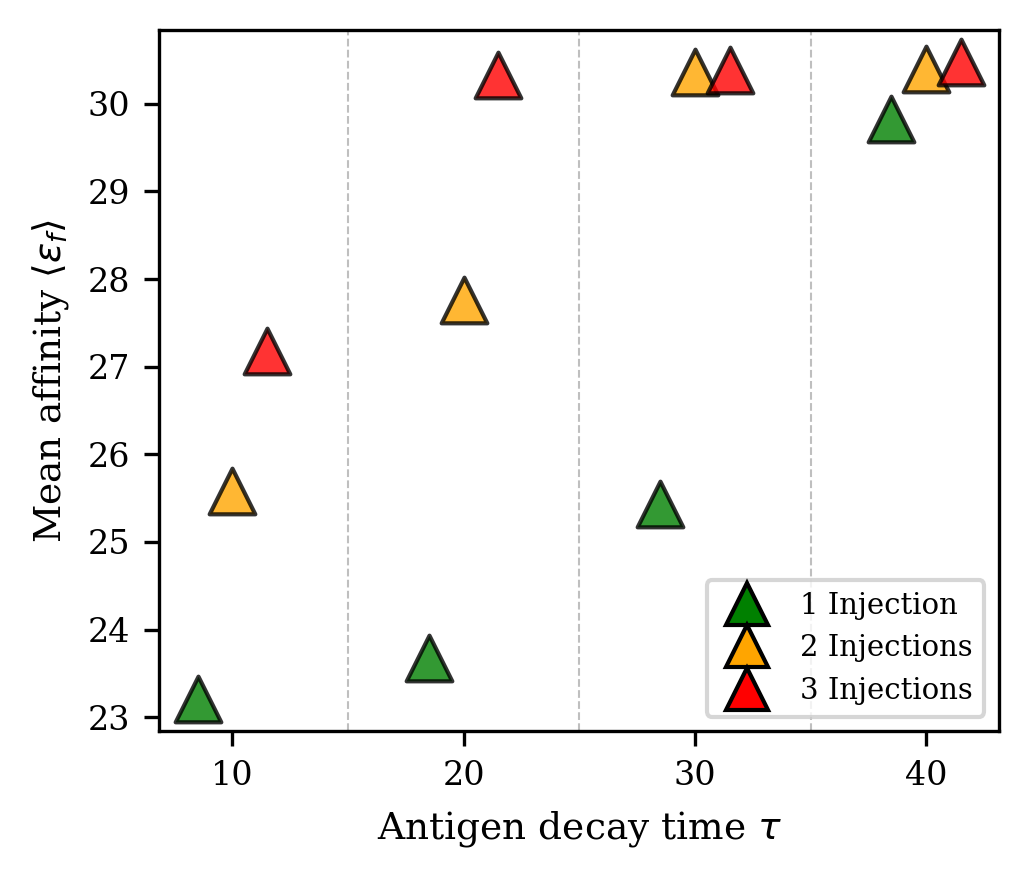

In [15]:


plt.figure(figsize=(3.5, 3))

colors_inj = {1: 'green', 2: 'orange', 3: 'red'}
labels_inj = {1: '1 Injection', 2: '2 Injections', 3: '3 Injections'}

offsets_inj = {1: -1.5, 2: 0.0, 3: 1.5} 

markers_tau = {10.0: '^', 20.0: '^', 30.0: '^', 40.0: '^'}
labels_tau = {10.0: r'$\tau=10$', 20.0: r'$\tau=20$', 30.0: r'$\tau=30$', 40.0: r'$\tau=40$'}

for N_injections in N_inj_array:
    current_results = results[N_injections]
    
    for item in current_results:
        tau_val = item[0]
        mean = item[1]
        concentrations = item[2]
        
        # Apply the horizontal shift based on the number of injections
        shifted_tau = tau_val + offsets_inj[N_injections]
        
        try: 
            plt.scatter(
                shifted_tau, 
                mean, 
                marker=markers_tau[tau_val], 
                color=colors_inj[N_injections],
                s=120,
                alpha=0.8,
                edgecolors='k' # Add a black edge for better visibility
            )
        except KeyError:
            print ("missing item")
#add vertical dashed lmines between the tau  to separate the tau values
for tau_val in Tau_array[:-1]:
    plt.axvline(x=tau_val+5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

legend_elements_inj = [
    mlines.Line2D([0], [0], marker='^', color='w', label=labels_inj[n], 
                  markerfacecolor=colors_inj[n], markeredgecolor='k', markersize=10) 
    for n in N_inj_array
]

legend_elements_tau = [
    mlines.Line2D([0], [0], marker=markers_tau[t], color='w', label=labels_tau[t], 
                  markerfacecolor='gray', markeredgecolor='k', markersize=10) 
    for t in Tau_array
]

combined_legend_elements = legend_elements_inj 

plt.legend(handles=combined_legend_elements, loc='lower right', fontsize=7)

plt.xlabel(r'Antigen decay time $\tau$')
plt.ylabel(r"Mean affinity $\langle \epsilon_f \rangle$")

plt.xticks(list(Tau_array))

plt.tight_layout()
plt.show()


# Comparison with stochastic trajectories

In [ ]:

def get_schedule_from_inj(C_opt, t_opt, tau):
    C_opt = np.array(C_opt)
    t_opt = np.array(t_opt)
    
    def get_c(t):
        # Handle both scalar and array inputs for t
        t_is_scalar = np.isscalar(t)
        t_arr = np.atleast_1d(t)
        
        C_total = np.zeros_like(t_arr, dtype=float)
        
        # Add the decaying concentration for each injection that has already occurred
        for c_val, t_val in zip(C_opt, t_opt):
            mask = t_arr >= t_val
            C_total[mask] += c_val * np.exp(-(t_arr[mask] - t_val) / tau)
            
        # Guarantee the output is a numpy array to match your simulation's expectations
        if t_is_scalar:
            return np.array([C_total[0]])
        else:
            return C_total
        
    return get_c

# --- 3 id vaccine ---
function = get_schedule_from_inj(
    C_opt=[31.125742645812362, 31.125742645812362, 31.125742645812362],
    t_opt=[0., 56, 112],# every 4 weeks
    tau=20.0
)
df_created_schedule= pd.DataFrame({
    'time': np.linspace(0, 140, 28001),
    'C': function(np.linspace(0, 140, 28001))
})

def C_schedule_Ninj3id(t):
    return np.array([np.interp(t, df_created_schedule['time'], df_created_schedule['C'])])



In [25]:
df_vacc = pd.read_csv("../PDE/optimized_vaccine_concentration_opti.csv")

def C_schedule_Ninj3(t):
    return np.array([np.interp(t, df_vacc['time'], df_vacc['C_vaccine_Ninj3'])])

def C_schedule_Ninj2(t):
    return np.array([np.interp(t, df_vacc['time'], df_vacc['C_vaccine_Ninj2'])])

def C_schedule_Ninj1(t):
    return np.array([np.interp(t, df_vacc['time'], df_vacc['C_vaccine_Ninj1'])])


schedules = {
    r'$N_{inj}=3$': C_schedule_Ninj3,
    r'$N_{inj}=2$': C_schedule_Ninj2,
    r'$N_{inj}=1$': C_schedule_Ninj1,
    r'$N_{inj}=3$ id': C_schedule_Ninj3id,
    'C=5': lambda t, val=5: np.array([val]),
    'C=10': lambda t, val=10: np.array([val]),
    'C=20': lambda t, val=20: np.array([val]),


}

In [26]:

# Dictionary to hold the final mean affinities for each schedule across the seeds
results_mean_aff = {name: [] for name in schedules.keys()}

for sched_name, sched_func in schedules.items():
    print(f"--- Running simulations for schedule: {sched_name} ---")
    
    for seed in range(10):
        print(f"Simulating seed {seed}...")
        
        history = simulate_gc_with_ancestry(
  
            C_schedule=sched_func,   # Passes the current schedule function

            seed=seed,                   
     
        )
        
     
        target_frame =  history[-1]
        # if len(target_frame['pop']) <1:
        #     results_mean_aff[sched_name].append(0)
        #     continue
                
 

        final_pop = target_frame['pop']

        # Calculate total affinities (sum of h_i) for the target population
        final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
        mean_affinity = final_affinities.mean()
        #check not nan
        if np.isnan(mean_affinity):
            print(f"  Warning: Mean affinity is NaN for seed {seed}. Defaulting to 0.")
            mean_affinity = 0.0
        
        # Store the result
        results_mean_aff[sched_name].append(mean_affinity)



--- Running simulations for schedule: $N_{inj}=3$ ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...
--- Running simulations for schedule: $N_{inj}=2$ ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...
--- Running simulations for schedule: $N_{inj}=1$ ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...
--- Running simulations for schedule: $N_{inj}=3$ id ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simu

C:\Users\maria\AppData\Local\Temp\ipykernel_8512\1915263746.py:30: RuntimeWarning: Mean of empty slice.
  mean_affinity = final_affinities.mean()
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...
--- Running simulations for schedule: C=10 ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...
--- Running simulations for schedule: C=20 ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...


C:\Users\maria\AppData\Local\Temp\ipykernel_8512\1325201710.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)


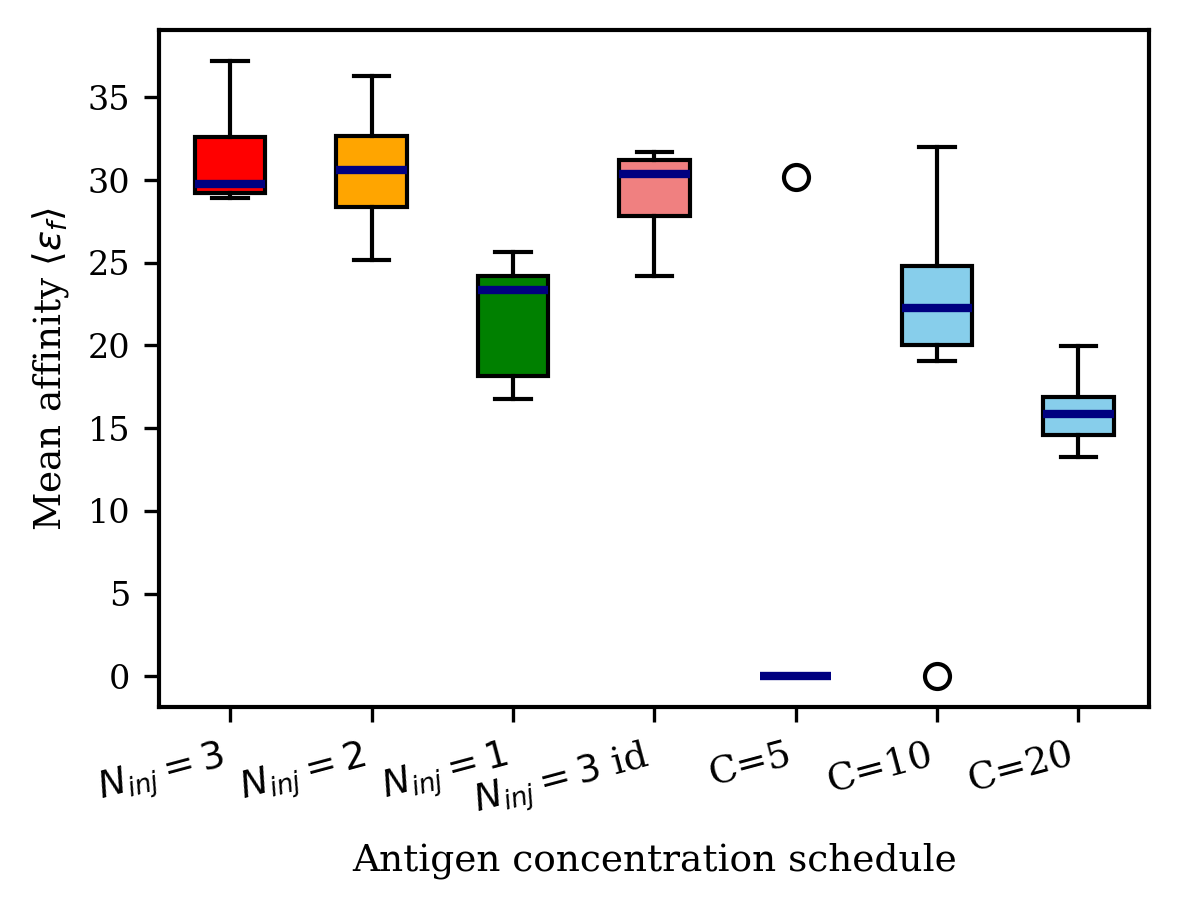

In [27]:
# --- Create the Candle Plot (Boxplot) ---
plt.figure(figsize=(4, 3.1), dpi=300)

# Extract data arrays and corresponding labels in the correct order
labels = list(results_mean_aff.keys())
data_to_plot = [results_mean_aff[label] for label in labels]
#remove opti from the plot
labels = [label for label in labels if label != 'Opti']
data_to_plot = [results_mean_aff[label] for label in labels if label != 'Opti']

# Create the boxplot
box = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)

# Formatting the box colors for visual distinction
for patch, label in zip(box['boxes'], labels):

    if label == r'$N_{inj}=3$':
        patch.set_facecolor('red')
    elif label == r'$N_{inj}=2$':
        patch.set_facecolor('orange')
    elif label == r'$N_{inj}=1$':
        patch.set_facecolor('green')
    elif 'inj' in label:
        patch.set_facecolor('lightcoral')
    else:
        patch.set_facecolor('skyblue')
        
# Set styling
plt.setp(box['medians'], color='navy', linewidth=2)

plt.xlabel("Antigen concentration schedule", fontsize=9)
plt.ylabel(r'Mean affinity $\langle \epsilon_f \rangle$')
#size of x labels
plt.xticks(rotation=15, ha='right', fontsize=9)
# plt.title("Mean Affinity Comparison (last pop)")
# plt.grid(True, linestyle=':', alpha=0.6, axis='y')
plt.tight_layout()
#change frame to be thicker
plt.gca().spines['top'].set_linewidth(1.)
plt.gca().spines['right'].set_linewidth(1.)
plt.gca().spines['left'].set_linewidth(1.)
plt.gca().spines['bottom'].set_linewidth(1.)

plt.show()
